# Project: Computer Vision

**Task 2: Classifying Fashion Products**

Author: James Antony Das

**Introduction**

The objective of this task is to develop a Random Forest Classifier and CNN model on the Fashion-MNIST data, and evaluate the model



## Importing the necessary libraries

In [ ]:
# loading the necessary datasets
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# Import the models and dataset
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.ensemble import RandomForestClassifier

# Import the evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Loading the dataset

In [ ]:
# Load the dataset
print("Loading FashionMNIST data...")
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

Loading FashionMNIST data...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# dimensions of the datasets
print('Train Shape:', X_train.shape, y_train.shape)
print('Test Shape:', X_test.shape, y_test.shape)

Train Shape: (60000, 28, 28) (60000,)
Test Shape: (10000, 28, 28) (10000,)


In [ ]:
# The class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

## Exploratory Data Analysis

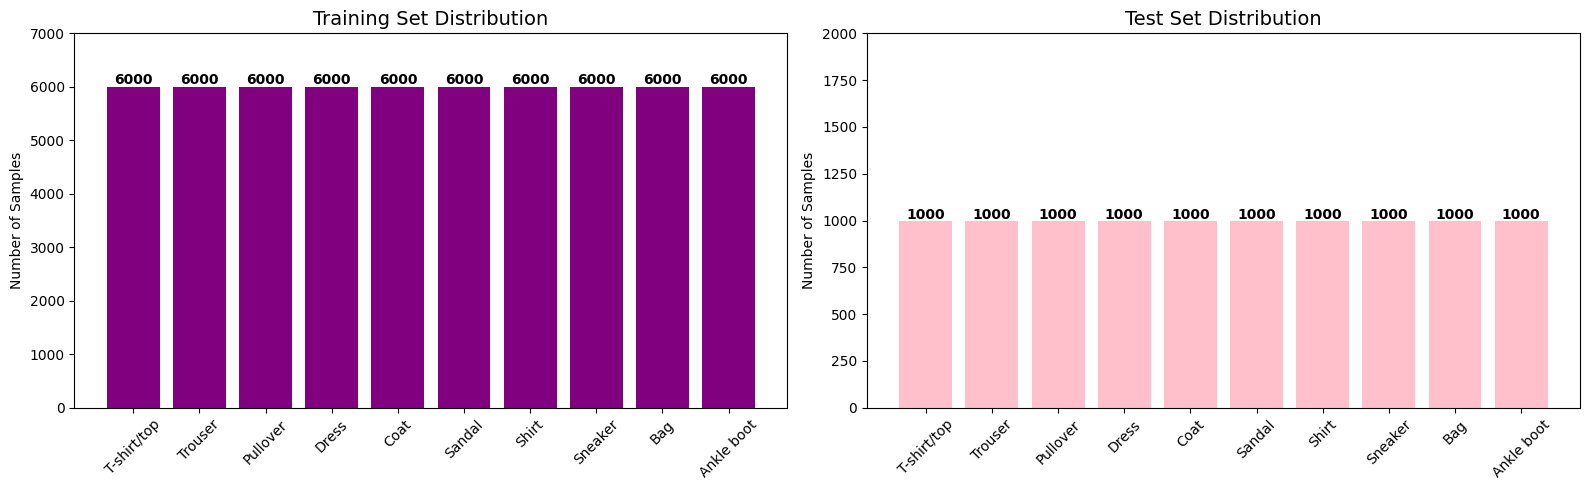

In [ ]:
# 3. Calculate frequencies
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

# 4. Create Subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# Plot 1: Training Set
axes[0].bar(class_names, counts_train, color='purple')
axes[0].set_title('Training Set Distribution', fontsize=14)
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 7000)

# Plot 2: Test Set
axes[1].bar(class_names, counts_test, color='pink')
axes[1].set_title('Test Set Distribution', fontsize=14)
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 2000)

# Add value labels on top of the bars for both plots
for ax, counts in zip(axes, [counts_train, counts_test]):
    for i, v in enumerate(counts):
        ax.text(i, v + (max(counts) * 0.01), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

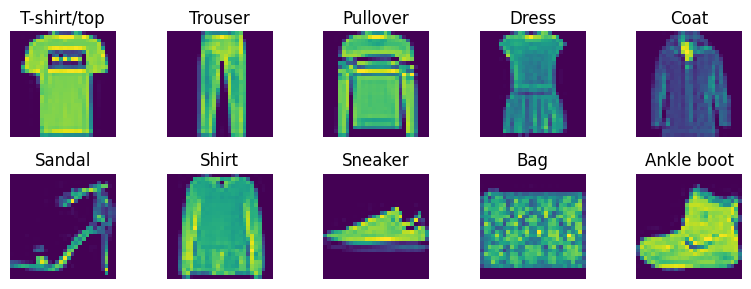

In [ ]:
# 3. Plotting logic
plt.figure(figsize=(8, 3))

for i in range(10):
    # Find the index of the first image belonging to class 'i'
    index = np.where(y_train == i)[0][0]
    image = X_train[index]

    # Create a subplot for each class
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='viridis')
    plt.title(f"{class_names[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [ ]:
# Normalize pixel values to be between 0 and 1
X_train_normal = X_train / 255.0
X_test_normal = X_test / 255.0

In [ ]:
# Flatten the images: (60000, 28, 28) -> (60000, 784)
X_train_rf = X_train_normal.reshape(X_train_normal.shape[0], -1)
X_test_rf = X_test_normal.reshape(X_test_normal.shape[0], -1)

In [ ]:
# Reshape to (28, 28, 1) and normalize pixels to [0, 1]
X_train_cnn = X_train_normal.reshape((60000, 28, 28, 1)).astype("float32")
X_test_cnn = X_test_normal.reshape((10000, 28, 28, 1)).astype("float32")

**Define some functions for Evaluation**

In [ ]:
def evaluate_model(y_true, y_pred):
  """function for evaluating the model"""
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  return accuracy, precision, recall, f1

def evaluation_table(y_train, y_pred_train, y_test, y_pred_test):
  """function for printing the evaluation table"""
  train_metrics = evaluate_model(y_train, y_pred_train)
  test_metrics = evaluate_model(y_test, y_pred_test)

  table_data = [
        ['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1 score'],
        ['Training set', f'{train_metrics[0]:.4f}', f'{train_metrics[1]:.4f}', f'{train_metrics[2]:.4f}', f'{train_metrics[3]:.4f}'],
        ['Test set', f'{test_metrics[0]:.4f}', f'{test_metrics[1]:.4f}', f'{test_metrics[2]:.4f}', f'{test_metrics[3]:.4f}']
    ]
  print(tabulate(table_data, headers="firstrow", tablefmt="fancy_grid"))
  return None

def confusion_matrix_plot(y_true, y_pred, class_names, color='Blues', title='Confusion Matrix'):
    """Function to calculate Calculate the confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    # Create a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
    return None

def misclassified_sample(y_true, y_pred, class_names):
    """Function to print misclassified samples"""
    # Find misclassified samples
    misclassified_idx = np.where(y_pred != y_true)[0]
    # 2. Setup the plot
    plt.figure(figsize=(8, 5))

    # 3. Plot the first 10 misclassified examples
    for i, idx in enumerate(misclassified_idx[:10]):
        plt.subplot(2, 5, i + 1)

        # Reshape the flattened test data back to 28x28 for display
        plt.imshow(X_test[idx], cmap='viridis')

        actual_label = class_names[y_test[idx]]
        predicted_label = class_names[y_pred[idx]]

        plt.title(f"Act: {actual_label}\nPred: {predicted_label}")
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## Random Forest Classifier

In [ ]:
# fitting the model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=100, criterion='entropy', random_state=42)
rf_Start_time = time.time()
rf_model.fit(X_train_rf, y_train)
rf_End_time = time.time()
rf_model

RandomForestClassifier(criterion='entropy', max_depth=100, random_state=42)

In [ ]:
print(f"Training time (RF Classifier): {rf_End_time - rf_Start_time:.2f} seconds")

Training time (RF Classifier): 149.68 seconds


In [ ]:
# save rf_model
import pickle
pickle.dump(rf_model, open('rf_model.pkl', 'wb'))

In [ ]:
# Make Predictions
rf_pred_start_time = time.time()
y_pred_train_rf = rf_model.predict(X_train_rf)
y_pred_test_rf = rf_model.predict(X_test_rf)
rf_pred_end_time = time.time()

print(f"Prediction time (RF Classifier): {rf_pred_end_time - rf_pred_start_time:.2f} seconds")

Prediction time (RF Classifier): 5.25 seconds


In [ ]:
# average prediction time
avg_pred_time = (rf_pred_end_time - rf_pred_start_time) / (len(y_pred_train_rf) + len(y_pred_test_rf))
print(f"Average prediction time (RF Classifier): {avg_pred_time:.5f} seconds")

Average prediction time (RF Classifier): 0.00008 seconds


In [ ]:
# 4. Make Predictions
y_pred_train_rf = rf_model.predict(X_train_rf)
y_pred_test_rf = rf_model.predict(X_test_rf)

In [ ]:
evaluation_table(y_train, y_pred_train_rf, y_test, y_pred_test_rf)

╒══════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Dataset      │   Accuracy │   Precision │   Recall │   F1 score │
╞══════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Training set │     1      │      1      │   1      │     1      │
├──────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Test set     │     0.8773 │      0.8762 │   0.8773 │     0.8758 │
╘══════════════╧════════════╧═════════════╧══════════╧════════════╛


In [ ]:
# classification report RF Classifier for training set
print(classification_report(y_train, y_pred_train_rf, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       1.00      1.00      1.00      6000
     Trouser       1.00      1.00      1.00      6000
    Pullover       1.00      1.00      1.00      6000
       Dress       1.00      1.00      1.00      6000
        Coat       1.00      1.00      1.00      6000
      Sandal       1.00      1.00      1.00      6000
       Shirt       1.00      1.00      1.00      6000
     Sneaker       1.00      1.00      1.00      6000
         Bag       1.00      1.00      1.00      6000
  Ankle boot       1.00      1.00      1.00      6000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



In [ ]:
# classification report on RF Classifier on Test set
print(classification_report(y_test, y_pred_test_rf, target_names=class_names))


              precision    recall  f1-score   support

 T-shirt/top       0.82      0.87      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.80      0.78      1000
       Dress       0.88      0.91      0.89      1000
        Coat       0.76      0.81      0.79      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.72      0.59      0.65      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.95      0.97      0.96      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



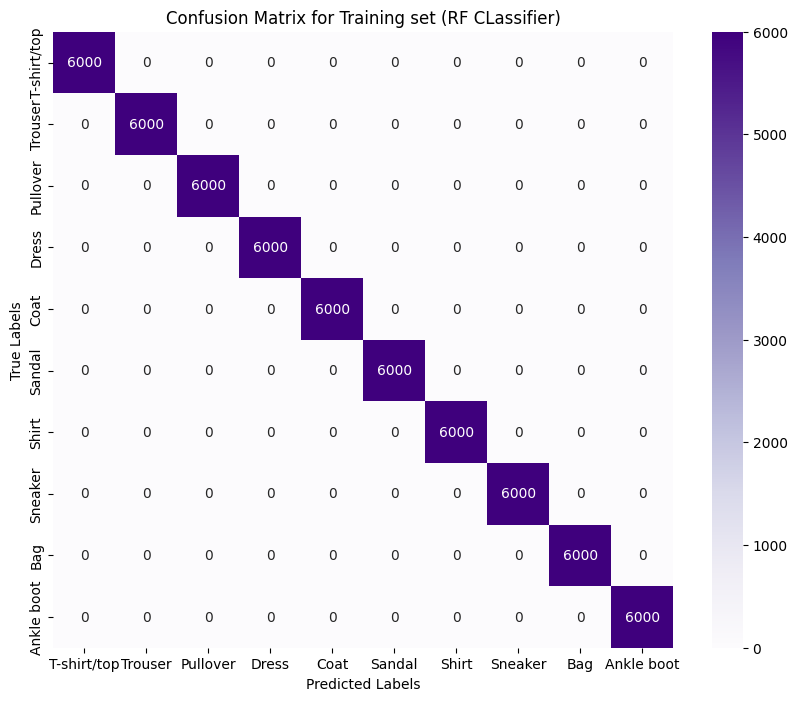

In [ ]:
confusion_matrix_plot(y_train, y_pred_train_rf, class_names, color='Purples',
                      title='Confusion Matrix for Training set (RF CLassifier)')

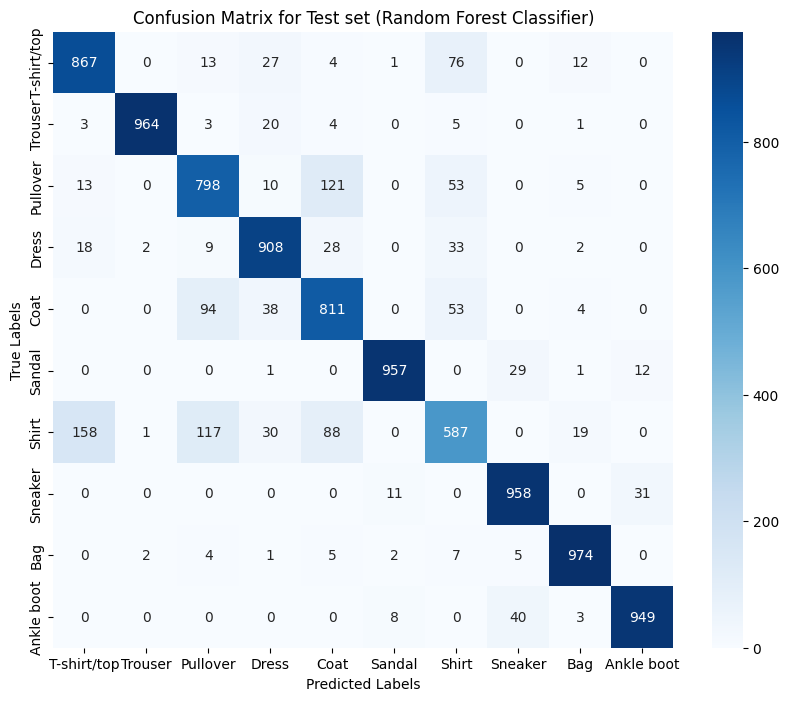

In [ ]:
confusion_matrix_plot(y_test, y_pred_test_rf, class_names, title='Confusion Matrix for Test set (Random Forest Classifier)')

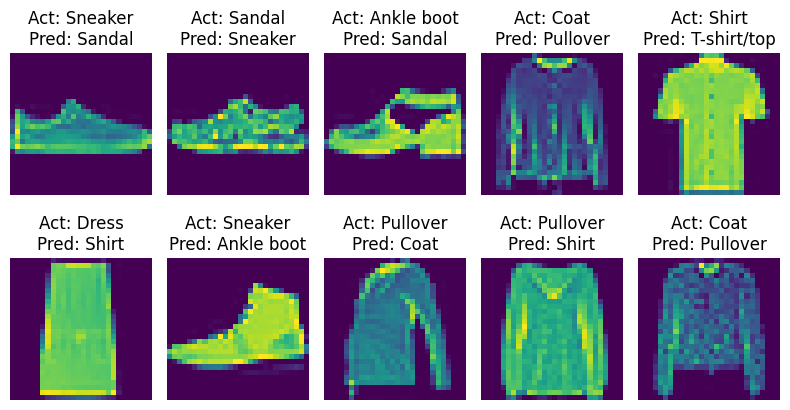

In [ ]:
misclassified_sample(y_test, y_pred_test_rf, class_names)

## Convolutional Neural Network

In [ ]:
# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Using CPU')
else:
    print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
# ignore warning
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Build the Model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flattening and Dense Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Dropout helps prevent overfitting
    layers.Dense(10, activation='softmax') # 10 classes for Fashion-MNIST
])

# Compile the Model
cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

cnn_Start_time = time.time()
# fitting the model
history = cnn_model.fit(X_train_cnn, y_train,
                        epochs=100,
                        validation_split=0.1,
                        batch_size=128,
                        callbacks=[early_stopping])
cnn_End_time = time.time()

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.6523 - loss: 0.9857 - val_accuracy: 0.8477 - val_loss: 0.4187
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8445 - loss: 0.4313 - val_accuracy: 0.8668 - val_loss: 0.3578
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8694 - loss: 0.3565 - val_accuracy: 0.8848 - val_loss: 0.3125
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8879 - loss: 0.3110 - val_accuracy: 0.8913 - val_loss: 0.2939
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8961 - loss: 0.2868 - val_accuracy: 0.8995 - val_loss: 0.2818
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9026 - loss: 0.2686 - val_accuracy: 0.9037 - val_loss: 0.2645
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9093 - loss: 0.2469 - val_accuracy: 0.9037 - val_loss: 0.2629
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9158 - loss: 0.2298 - val_ac

In [ ]:
print(f"Training time (CNN): {cnn_End_time - cnn_Start_time:.2f} seconds")

Training time (CNN): 75.91 seconds


In [ ]:
# save model
cnn_model.save('cnn_model.keras')

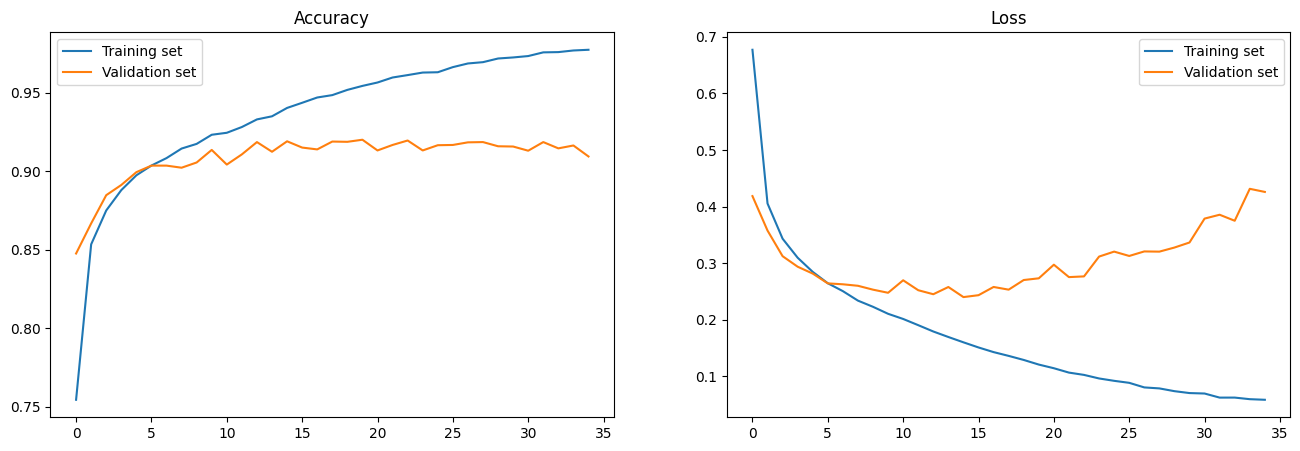

In [ ]:
def plot_training_history(data):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    # Plot Accuracy
    ax1.plot(data['accuracy'], label='Training set')
    ax1.plot(data['val_accuracy'], label='Validation set')
    ax1.set_title('Accuracy')
    ax1.legend()

    # Plot Loss
    ax2.plot(data['loss'], label='Training set')
    ax2.plot(data['val_loss'], label='Validation set')
    ax2.set_title('Loss')
    ax2.legend()

    plt.show()

plot_training_history(cnn_history)

In [ ]:
# prediction for CNN model
cnn_pred_start_time = time.time()
y_pred_train_cnn = cnn_model.predict(X_train_cnn)
y_pred_train_cnn = np.argmax(y_pred_train_cnn, axis=1)

y_pred_test_cnn = cnn_model.predict(X_test_cnn)
y_pred_test_cnn = np.argmax(y_pred_test_cnn, axis=1)
cnn_pred_end_time = time.time()

print(f"Prediction time (CNN): {cnn_pred_end_time - cnn_pred_start_time:.2f} seconds")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction time (CNN): 13.15 seconds


In [ ]:
evaluation_table(y_train, y_pred_train_cnn, y_test, y_pred_test_cnn)

╒══════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Dataset      │   Accuracy │   Precision │   Recall │   F1 score │
╞══════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Training set │     0.9494 │      0.9493 │   0.9494 │     0.9492 │
├──────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Test set     │     0.9101 │      0.91   │   0.9101 │     0.9098 │
╘══════════════╧════════════╧═════════════╧══════════╧════════════╛


In [ ]:
# classification report for CNN on Training set
print(classification_report(y_train, y_pred_train_cnn, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.92      0.91      0.91      6000
     Trouser       0.99      0.99      0.99      6000
    Pullover       0.91      0.93      0.92      6000
       Dress       0.96      0.95      0.95      6000
        Coat       0.89      0.93      0.91      6000
      Sandal       1.00      0.99      0.99      6000
       Shirt       0.87      0.82      0.84      6000
     Sneaker       0.98      0.99      0.98      6000
         Bag       1.00      0.99      0.99      6000
  Ankle boot       0.99      0.98      0.98      6000

    accuracy                           0.95     60000
   macro avg       0.95      0.95      0.95     60000
weighted avg       0.95      0.95      0.95     60000



In [ ]:
# classification report for CNN on Test set
print(classification_report(y_test, y_pred_test_cnn, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.85      0.86      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.85      0.89      0.87      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.83      0.89      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.76      0.71      0.73      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



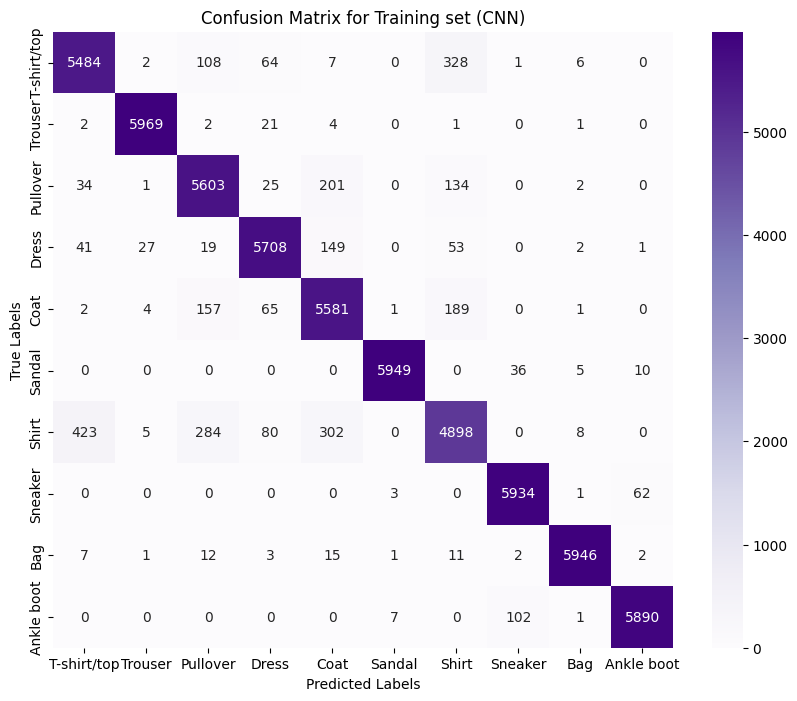

In [ ]:
confusion_matrix_plot(y_train, y_pred_train_cnn, class_names, color='Purples',
                      title='Confusion Matrix for Training set (CNN)')

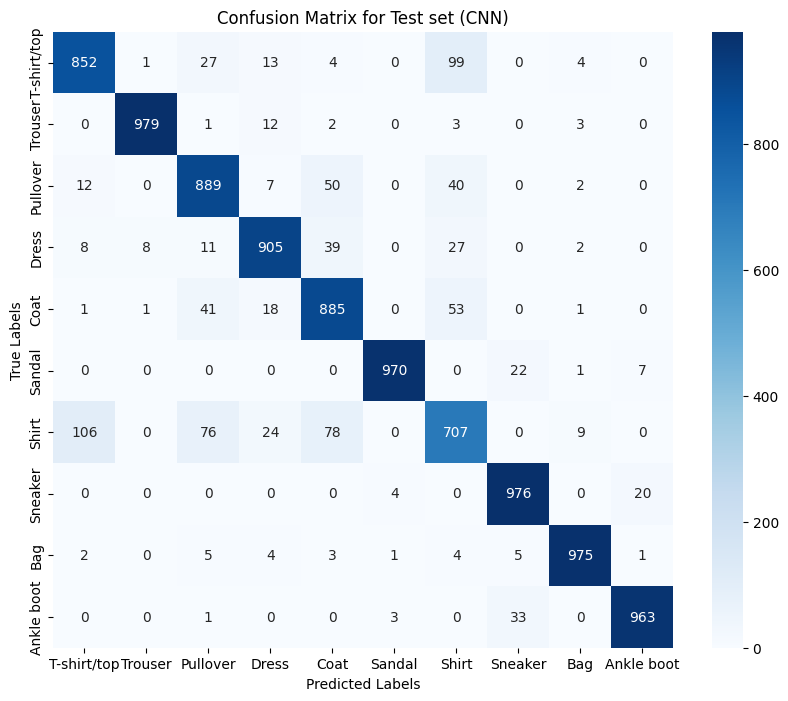

In [ ]:
confusion_matrix_plot(y_test, y_pred_test_cnn, class_names,
                      title='Confusion Matrix for Test set (CNN)')

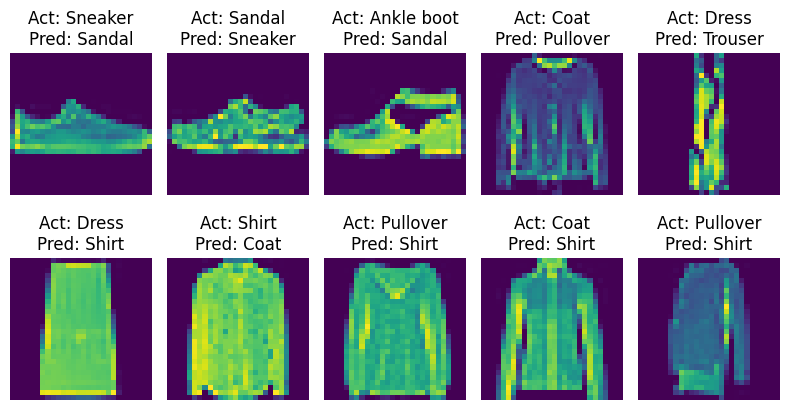

In [ ]:
misclassified_sample(y_test, y_pred_test_cnn, class_names)

## 3D Visualization using Principal Components

Loading data...
Running PCA...


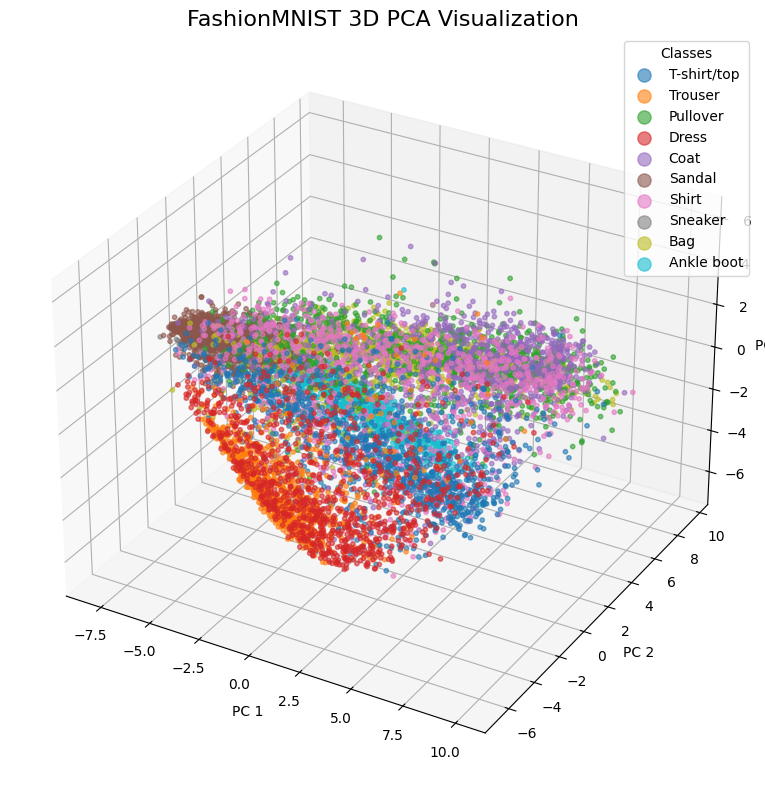

Total Variance Explained by 3 components: 52.82%


In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# 2. Preprocess
# Flatten images from (28, 28) to (784,)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
# Normalize to range [0, 1]
X_test_flat = X_test_flat / 255.0

# 3. Apply PCA for 3 Components
print("Running PCA...")
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_test_flat)

# 4. Define labels and colors
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 5. Create 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each class separately to add labels for the legend
for i in range(10):
    indices = np.where(y_test == i)
    ax.scatter(
        X_pca[indices, 0],
        X_pca[indices, 1],
        X_pca[indices, 2],
        label=class_names[i],
        alpha=0.6,
        s=10  # Point size
    )

# Formatting
ax.set_title("FashionMNIST 3D PCA Visualization", fontsize=16)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.legend(loc='best', markerscale=3, title="Classes")

plt.tight_layout()
plt.show()

# Print Variance Explained
print(f"Total Variance Explained by 3 components: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

**Conclusion**

Based on the observations of the projects, the CNN model shows better performance, without considerable overfitting on the training set.

**References**

Xiao, H., Rasul, K., & Vollgraf, R. (2017). Fashion-MNIST: A novel image dataset for benchmarking
machine learning algorithms. arXiv preprint arXiv:1708.07747. https://arxiv.org/pdf/1708.07747

Tensorflow (2024). Basic classification: Classify images of clothing.
https://www.tensorflow.org/tutorials/keras/classification [